# TLC Trip Data — Exploratory Analysis

Tasks 1–5: Schema · Nulls · FHV Sparsity · Fleet Mix · Temporal Patterns

**Fleet grouping model:** Yellow + Green form the **metered group** (taximeter, fixed fares). FHV + FHVHV form the **dispatched group** (app-based, dynamic pricing). Cross-group field comparisons (fare, distance) are only valid after explicit normalization. Zone IDs and timestamps are directly comparable across groups.

In [1]:
from pathlib import Path
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

RAW = Path("../data/raw/tlc_trips")

# Fleet files
FLEET = {
    "yellow": RAW / "yellow_tripdata_2025-01.parquet",
    "green":  RAW / "green_tripdata_2025-01.parquet",
    "fhv":    RAW / "fhv_tripdata_2025-01.parquet",
    "fhvhv":  RAW / "fhvhv_tripdata_2025-01.parquet",
}

# Two operationally distinct groups — analysis respects this split
METERED    = ["yellow", "green"]   # taximeter, fixed fares, passenger_count
DISPATCHED = ["fhv", "fhvhv"]     # app-based, dynamic pricing, no passenger_count

# Canonical pickup datetime column per fleet
PICKUP_COL = {
    "yellow": "tpep_pickup_datetime",
    "green":  "lpep_pickup_datetime",
    "fhv":    "pickup_datetime",
    "fhvhv":  "pickup_datetime",
}

# Canonical dropoff datetime column per fleet
DROPOFF_COL = {
    "yellow": "tpep_dropoff_datetime",
    "green":  "lpep_dropoff_datetime",
    "fhv":    "dropOff_datetime",
    "fhvhv":  "dropoff_datetime",
}

# Colors: consistent per fleet across all plots
FLEET_COLORS = {
    "yellow": "#f6c90e",
    "green":  "#4caf50",
    "fhv":    "#7986cb",
    "fhvhv":  "#ef5350",
}

# Group-level colors for cross-group plots
GROUP_COLORS = {"metered": "#2196f3", "dispatched": "#ff5722"}

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

## Task 1 — Schema Harmonization

Three-part analysis using pyarrow (zero data loaded):
1. **Metered group** — Yellow vs Green: shared fields, fleet-specific fields, poolability verdict
2. **Dispatched group** — FHV vs FHVHV: structural absences vs recoverable fields
3. **Cross-group common core** — only the fields genuinely comparable across groups (zone IDs, timestamps)

In [2]:
# Read schemas without loading data
schemas = {name: pq.read_schema(path) for name, path in FLEET.items()}

def schema_table(fleet_names):
    """Build a dtype comparison table for a subset of fleets."""
    rows = {}
    for name in fleet_names:
        for field in schemas[name]:
            rows.setdefault(field.name, {})[name] = str(field.type)
    return (
        pd.DataFrame(rows).T
        .reindex(columns=fleet_names)
        .fillna("—")
        .rename_axis("column")
    )

# ── Part 1: Metered group ────────────────────────────────────────────────────
metered_df = schema_table(METERED)
print("METERED GROUP (Yellow vs Green)")
display(metered_df.style.apply(
    lambda col: ["background-color: #fff9c4" if v == "—" else "" for v in col], axis=0
))

shared_m   = [c for c in metered_df.index if (metered_df.loc[c] != "—").all()]
yellow_only = [c for c in metered_df.index if metered_df.loc[c, "green"] == "—"]
green_only  = [c for c in metered_df.index if metered_df.loc[c, "yellow"] == "—"]
print(f"\nShared ({len(shared_m)}):      {shared_m}")
print(f"Yellow-only ({len(yellow_only)}): {yellow_only}")
print(f"Green-only ({len(green_only)}):  {green_only}")

METERED GROUP (Yellow vs Green)


,yellow,green
column,,
VendorID,int32,int32
tpep_pickup_datetime,timestamp[us],—
tpep_dropoff_datetime,timestamp[us],—
passenger_count,int64,int64
trip_distance,double,double
RatecodeID,int64,int64
store_and_fwd_flag,large_string,large_string
PULocationID,int32,int32
DOLocationID,int32,int32



Shared (17):      ['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'cbd_congestion_fee']
Yellow-only (3): ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'Airport_fee']
Green-only (4):  ['lpep_pickup_datetime', 'lpep_dropoff_datetime', 'ehail_fee', 'trip_type']


In [3]:
# ── Part 2: Dispatched group ─────────────────────────────────────────────────
dispatched_df = schema_table(DISPATCHED)
print("DISPATCHED GROUP (FHV vs FHVHV)")
display(dispatched_df.style.apply(
    lambda col: ["background-color: #fff9c4" if v == "—" else "" for v in col], axis=0
))

shared_d  = [c for c in dispatched_df.index if (dispatched_df.loc[c] != "—").all()]
fhv_only  = [c for c in dispatched_df.index if dispatched_df.loc[c, "fhvhv"] == "—"]
fhvhv_only = [c for c in dispatched_df.index if dispatched_df.loc[c, "fhv"] == "—"]
print(f"\nShared ({len(shared_d)}):       {shared_d}")
print(f"FHV-only ({len(fhv_only)}):     {fhv_only}")
print(f"FHVHV-only ({len(fhvhv_only)}): {fhvhv_only}")

DISPATCHED GROUP (FHV vs FHVHV)


,fhv,fhvhv
column,,
dispatching_base_num,large_string,large_string
pickup_datetime,timestamp[us],timestamp[us]
dropOff_datetime,timestamp[us],—
PUlocationID,int64,—
DOlocationID,int64,—
SR_Flag,int64,—
Affiliated_base_number,large_string,—
hvfhs_license_num,—,large_string
originating_base_num,—,large_string



Shared (2):       ['dispatching_base_num', 'pickup_datetime']
FHV-only (5):     ['dropOff_datetime', 'PUlocationID', 'DOlocationID', 'SR_Flag', 'Affiliated_base_number']
FHVHV-only (23): ['hvfhs_license_num', 'originating_base_num', 'request_datetime', 'on_scene_datetime', 'dropoff_datetime', 'PULocationID', 'DOLocationID', 'trip_miles', 'trip_time', 'base_passenger_fare', 'tolls', 'bcf', 'sales_tax', 'congestion_surcharge', 'airport_fee', 'tips', 'driver_pay', 'shared_request_flag', 'shared_match_flag', 'access_a_ride_flag', 'wav_request_flag', 'wav_match_flag', 'cbd_congestion_fee']


In [4]:
# ── Part 3: Cross-group common core ─────────────────────────────────────────
# Only zone IDs and timestamps are directly comparable across groups.
# Fare and distance fields are analogous but not equivalent.
CROSS_GROUP_CORE = pd.DataFrame([
    {
        "concept":        "pickup zone",
        "metered":        "PULocationID (int32)",
        "dispatched":     "PULocationID (int32) / PUlocationID float in fhv",
        "comparable":     "Yes — same 263-zone TLC system; fhv needs float→int cast",
    },
    {
        "concept":        "dropoff zone",
        "metered":        "DOLocationID (int32)",
        "dispatched":     "DOLocationID (int32) / DOlocationID float in fhv",
        "comparable":     "Yes — same caveat as above",
    },
    {
        "concept":        "pickup time",
        "metered":        "tpep_*/lpep_pickup_datetime",
        "dispatched":     "pickup_datetime",
        "comparable":     "Yes — same moment semantics, same timezone",
    },
    {
        "concept":        "dropoff time",
        "metered":        "tpep_*/lpep_dropoff_datetime",
        "dispatched":     "dropOff_datetime (fhv) / dropoff_datetime (fhvhv)",
        "comparable":     "Yes — same caveat as above",
    },
    {
        "concept":        "base fare",
        "metered":        "fare_amount (taximeter rate)",
        "dispatched":     "base_passenger_fare (dynamic pricing, fhvhv only)",
        "comparable":     "Analogous, NOT equivalent — different pricing models",
    },
    {
        "concept":        "trip distance",
        "metered":        "trip_distance (taximeter-reported, miles)",
        "dispatched":     "trip_miles (GPS-based, fhvhv only; absent in fhv)",
        "comparable":     "Same unit (miles), different measurement method",
    },
    {
        "concept":        "congestion surcharge",
        "metered":        "congestion_surcharge + cbd_congestion_fee",
        "dispatched":     "congestion_surcharge + cbd_congestion_fee (fhvhv only)",
        "comparable":     "Yes for fhvhv; absent in fhv",
    },
]).set_index("concept")

display(CROSS_GROUP_CORE)

,metered,dispatched,comparable
concept,,,
pickup zone,PULocationID (int32),PULocationID (int32) / PUlocationID float in fhv,Yes — same 263-zone TLC system; fhv needs floa...
dropoff zone,DOLocationID (int32),DOLocationID (int32) / DOlocationID float in fhv,Yes — same caveat as above
pickup time,tpep_*/lpep_pickup_datetime,pickup_datetime,"Yes — same moment semantics, same timezone"
dropoff time,tpep_*/lpep_dropoff_datetime,dropOff_datetime (fhv) / dropoff_datetime (fhvhv),Yes — same caveat as above
base fare,fare_amount (taximeter rate),"base_passenger_fare (dynamic pricing, fhvhv only)","Analogous, NOT equivalent — different pricing ..."
trip distance,"trip_distance (taximeter-reported, miles)","trip_miles (GPS-based, fhvhv only; absent in fhv)","Same unit (miles), different measurement method"
congestion surcharge,congestion_surcharge + cbd_congestion_fee,congestion_surcharge + cbd_congestion_fee (fhv...,Yes for fhvhv; absent in fhv


## Task 2 — Null / Missing Value Audit

Per-column null rates for every file. Heatmap **columns ordered by fleet group** (metered first, dispatched second) so structural absences (fhv's missing fare/distance fields) are visually distinct from data quality issues.

In [5]:
null_rates = {}
row_counts = {}

for fleet, path in FLEET.items():
    df = pd.read_parquet(path)
    row_counts[fleet] = len(df)
    null_rates[fleet] = (df.isnull().mean() * 100).round(1)

# Column order: metered group first, dispatched group second
GROUP_ORDER = METERED + DISPATCHED
null_df = pd.DataFrame(null_rates).reindex(columns=GROUP_ORDER).fillna(float("nan"))
null_df.index.name = "column"

# Flag columns with ≥20% nulls in at least one fleet
HIGH_NULL = 20.0
flagged = (null_df >= HIGH_NULL).any(axis=1)
if flagged.any():
    print(f"Columns with ≥{HIGH_NULL}% nulls in at least one fleet:")
    display(null_df[flagged].style
            .background_gradient(axis=None, cmap="Reds", vmin=0, vmax=100)
            .format("{:.1f}%", na_rep="—"))
else:
    print(f"No columns exceed {HIGH_NULL}% nulls in any fleet (excluding structurally absent fields shown as '—').")

Columns with ≥20.0% nulls in at least one fleet:


,yellow,green,fhv,fhvhv
column,,,,
PUlocationID,—,—,83.0%,—
SR_Flag,—,—,100.0%,—
ehail_fee,—,100.0%,—,—
on_scene_datetime,—,—,—,24.7%
originating_base_num,—,—,—,24.7%


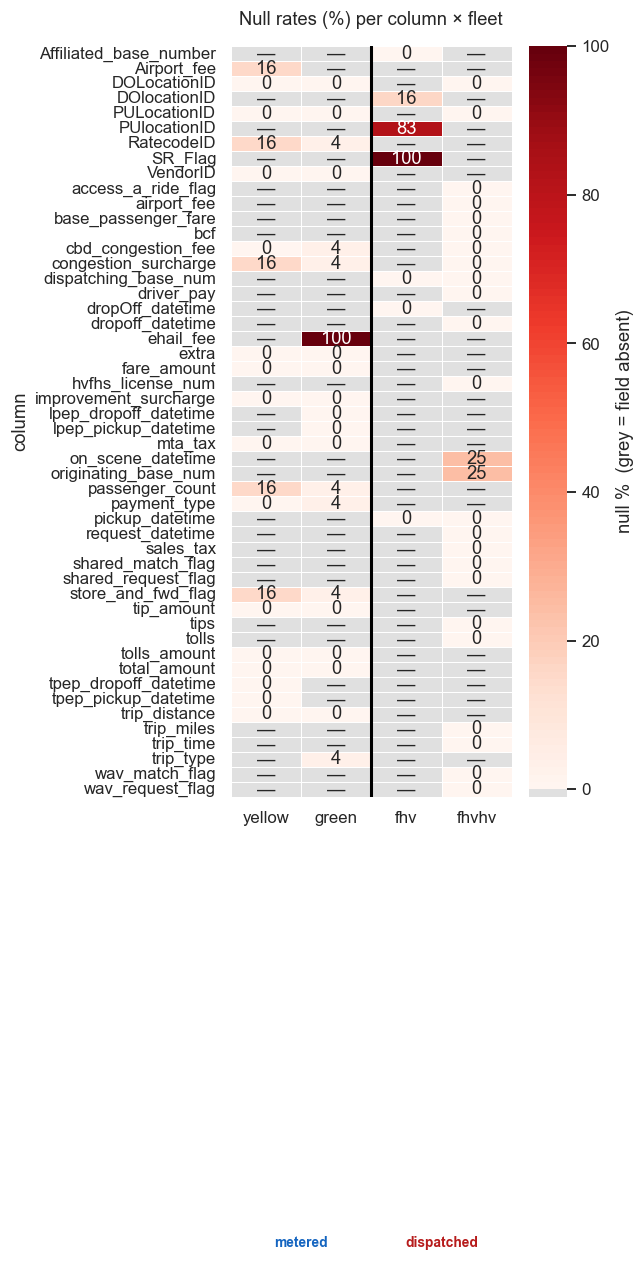

In [6]:
# Null heatmap — columns grouped: metered | dispatched
# NaN cells (field absent from that fleet) rendered in light grey to distinguish
# structural absences from real null rates
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(6, max(4, len(null_df) * 0.28)))

# Build a numeric matrix; use -1 as sentinel for "field absent"
plot_data = null_df.copy().fillna(-1)

# Custom colormap: grey for absent (-1), white-to-red for 0-100
cmap_base = plt.cm.Reds
colors_list = [(0.88, 0.88, 0.88)] + [cmap_base(i / 100) for i in range(101)]
custom_cmap = mcolors.LinearSegmentedColormap.from_list("grey_reds", colors_list, N=102)

annot_labels = plot_data.map(lambda v: "—" if v == -1 else f"{v:.0f}")  # pandas 2.x: map not applymap

sns.heatmap(
    plot_data,
    annot=annot_labels,
    fmt="s",
    cmap=custom_cmap,
    vmin=-1, vmax=100,
    linewidths=0.4,
    cbar_kws={"label": "null %  (grey = field absent)"},
    ax=ax,
)

# Vertical separator between metered and dispatched groups
ax.axvline(len(METERED), color="black", linewidth=2)
ax.text(len(METERED) / 2, -0.6, "metered", ha="center", fontsize=9, color="#1565c0", fontweight="bold",
        transform=ax.get_xaxis_transform())
ax.text(len(METERED) + len(DISPATCHED) / 2, -0.6, "dispatched", ha="center", fontsize=9,
        color="#b71c1c", fontweight="bold", transform=ax.get_xaxis_transform())

ax.set_title("Null rates (%) per column × fleet", pad=14)
ax.set_xlabel("")
plt.tight_layout()
plt.show()

## Task 3 - FHV Location Sparsity Decision Gate

FHV is the only fleet where location IDs appeared `NaN` in the first rows. Determine whether it can contribute to zone-based mobility features.

In [7]:
# Load only the columns needed for this gate
fhv = pd.read_parquet(
    FLEET["fhv"],
    columns=["dispatching_base_num", "PUlocationID", "DOlocationID"],
)

pu_pct = fhv["PUlocationID"].notna().mean() * 100
do_pct = fhv["DOlocationID"].notna().mean() * 100
print(f"FHV PUlocationID non-null: {pu_pct:.1f}%")
print(f"FHV DOlocationID non-null: {do_pct:.1f}%")

THRESHOLD = 30.0
verdict = "INCLUDE (location data sufficient)" if pu_pct >= THRESHOLD else "EXCLUDE from zone-based features (too sparse)"
print(f"\nDecision gate (threshold={THRESHOLD}%): {verdict}")

FHV PUlocationID non-null: 17.0%
FHV DOlocationID non-null: 83.9%

Decision gate (threshold=30.0%): EXCLUDE from zone-based features (too sparse)


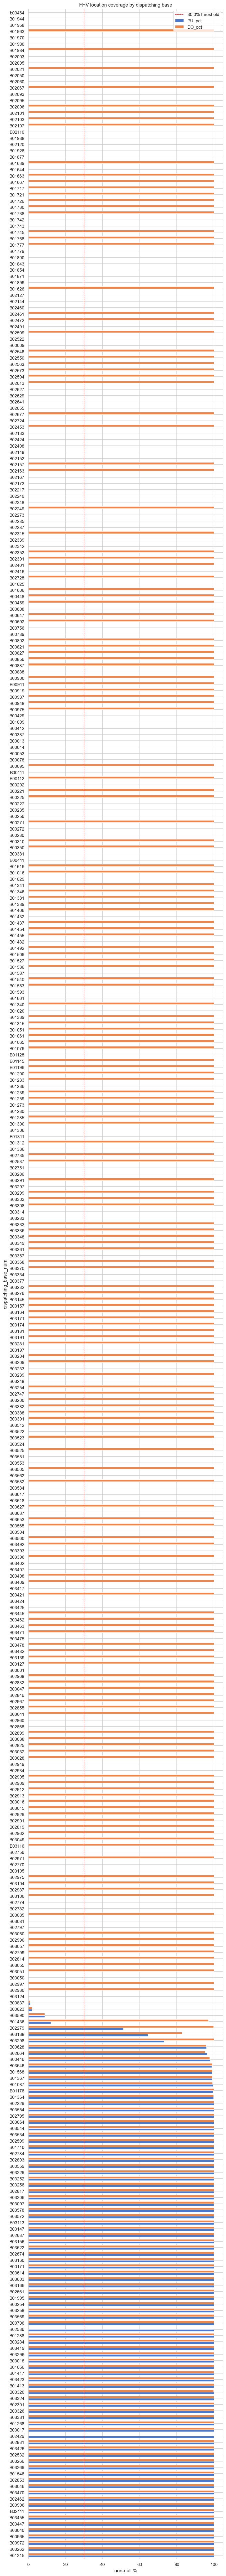

In [8]:
# Per-base location coverage — surface which operators have data
base_coverage = (
    fhv.groupby("dispatching_base_num")[["PUlocationID", "DOlocationID"]]
    .apply(lambda g: (g.notna().mean() * 100).round(1))
    .rename(columns={"PUlocationID": "PU_pct", "DOlocationID": "DO_pct"})
    .sort_values("PU_pct", ascending=False)
)

fig, ax = plt.subplots(figsize=(8, max(3, len(base_coverage) * 0.22)))
base_coverage[["PU_pct", "DO_pct"]].plot(kind="barh", ax=ax, width=0.7)
ax.axvline(THRESHOLD, color="red", linestyle="--", linewidth=1, label=f"{THRESHOLD}% threshold")
ax.set_xlabel("non-null %")
ax.set_title("FHV location coverage by dispatching base")
ax.legend()
plt.tight_layout()
plt.show()

del fhv  # free memory

## Task 4 — Fleet Mix & Volume Overview

Three-level breakdown: group totals → within-group shares → FHVHV platform split.
Green and FHV must be read in relation to their own group, not against fhvhv directly.

Group               Trips    Share
----------------------------------
metered         3,523,552    13.6%
dispatched     22,303,774    86.4%
TOTAL          25,827,326  100.0%

Within-group fleet breakdown:
  metered
    yellow      3,475,226    98.6% of group
    green          48,326     1.4% of group
  dispatched
    fhv         1,898,108     8.5% of group
    fhvhv      20,405,666    91.5% of group


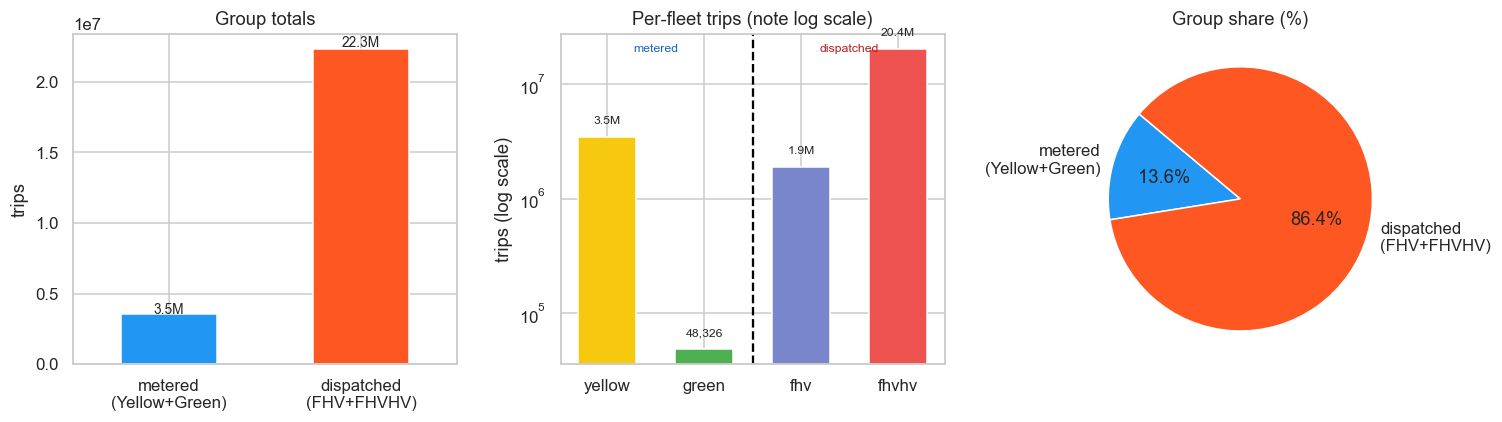

In [9]:
# row_counts populated in Task 2
metered_total    = sum(row_counts[f] for f in METERED)
dispatched_total = sum(row_counts[f] for f in DISPATCHED)
grand_total      = metered_total + dispatched_total

group_totals = pd.Series({"metered": metered_total, "dispatched": dispatched_total}, name="trips")

print(f"{'Group':<12} {'Trips':>12}  {'Share':>7}")
print("-" * 34)
for g, n in group_totals.items():
    print(f"{g:<12} {n:>12,}  {n/grand_total*100:>6.1f}%")
print(f"{'TOTAL':<12} {grand_total:>12,}  100.0%")

print("\nWithin-group fleet breakdown:")
for group, fleets in [("metered", METERED), ("dispatched", DISPATCHED)]:
    gtotal = group_totals[group]
    print(f"  {group}")
    for f in fleets:
        n = row_counts[f]
        print(f"    {f:<8} {n:>12,}  {n/gtotal*100:>6.1f}% of group")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel 1: group totals
group_totals.plot(kind="bar", ax=axes[0],
                  color=[GROUP_COLORS["metered"], GROUP_COLORS["dispatched"]], width=0.5)
axes[0].set_title("Group totals")
axes[0].set_ylabel("trips")
axes[0].set_xticklabels(["metered\n(Yellow+Green)", "dispatched\n(FHV+FHVHV)"], rotation=0)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                 f"{bar.get_height()/1e6:.1f}M", ha="center", fontsize=9)

# Panel 2: within-group shares (side-by-side, same axis is misleading — split by group color)
all_fleets_ordered = METERED + DISPATCHED
fleet_trips = [row_counts[f] for f in all_fleets_ordered]
bar_colors = [FLEET_COLORS[f] for f in all_fleets_ordered]
bars = axes[1].bar(all_fleets_ordered, fleet_trips, color=bar_colors, width=0.6)
axes[1].set_title("Per-fleet trips (note log scale)")
axes[1].set_yscale("log")
axes[1].set_ylabel("trips (log scale)")
axes[1].axvline(1.5, color="black", linewidth=1.5, linestyle="--")
axes[1].text(0.5, axes[1].get_ylim()[1] * 0.7, "metered", ha="center", fontsize=8, color="#1565c0")
axes[1].text(2.5, axes[1].get_ylim()[1] * 0.7, "dispatched", ha="center", fontsize=8, color="#b71c1c")
for bar, fleet in zip(bars, all_fleets_ordered):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.3,
                 f"{row_counts[fleet]/1e6:.1f}M" if row_counts[fleet] > 1e5 else f"{row_counts[fleet]:,}",
                 ha="center", fontsize=8)

# Panel 3: group share pie
axes[2].pie(group_totals, labels=["metered\n(Yellow+Green)", "dispatched\n(FHV+FHVHV)"],
            autopct="%1.1f%%",
            colors=[GROUP_COLORS["metered"], GROUP_COLORS["dispatched"]], startangle=140)
axes[2].set_title("Group share (%)")

plt.tight_layout()
plt.show()

                      trips  share_pct
hvfhs_license_num                     
Uber               15356455       75.3
Lyft                5049211       24.7


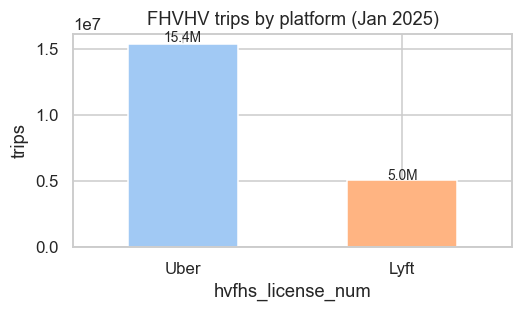

In [10]:
# FHVHV platform breakdown — load only the license column
PLATFORM_NAMES = {
    "HV0002": "Juno",
    "HV0003": "Uber",
    "HV0004": "Via",
    "HV0005": "Lyft",
}

fhvhv_license = pd.read_parquet(FLEET["fhvhv"], columns=["hvfhs_license_num"])
platform_counts = (
    fhvhv_license["hvfhs_license_num"]
    .map(PLATFORM_NAMES)
    .value_counts()
    .rename("trips")
    .to_frame()
    .assign(share_pct=lambda d: (d["trips"] / d["trips"].sum() * 100).round(1))
)
print(platform_counts.to_string())

fig, ax = plt.subplots(figsize=(5, 3))
platform_counts["trips"].plot(kind="bar", ax=ax, color=sns.color_palette("pastel", len(platform_counts)))
ax.set_title("FHVHV trips by platform (Jan 2025)")
ax.set_ylabel("trips")
ax.set_xticklabels(platform_counts.index, rotation=0)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
            f"{bar.get_height()/1e6:.1f}M", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

del fhvhv_license

## Task 5 — Temporal Distributions (Hour-of-Day & Day-of-Week)

Three plots:
- **Plot A** — Metered group: yellow and green **overlaid** (normalised %). Tests poolability.
- **Plot B** — Dispatched group: fhvhv hour-of-day. fhv shown separately for reference.
- **Plot C** — Cross-group: metered aggregate vs fhvhv aggregate. Timestamps are directly comparable across groups — reveals whether the two populations have different time-of-day preferences.

Meal-time windows annotated on all plots: lunch (11–14h), dinner (17–21h), late-night (22–02h).

In [11]:
MEAL_WINDOWS = [
    ("lunch",      11, 14,   "#ffe0b2"),
    ("dinner",     17, 21,   "#fce4ec"),
    ("late-night", 22, 23.5, "#e8eaf6"),
]

def add_meal_shading(ax):
    for label, h_start, h_end, color in MEAL_WINDOWS:
        ax.axvspan(h_start, h_end, alpha=0.35, color=color, zorder=0)

# Load only pickup datetime per fleet
hourly = {}
dow    = {}
for fleet, path in FLEET.items():
    col = PICKUP_COL[fleet]
    s = pd.read_parquet(path, columns=[col])[col]
    hourly[fleet] = s.dt.hour.value_counts().sort_index()
    dow[fleet]    = s.dt.dayofweek.value_counts().sort_index()

# Normalise to share (%)
hourly_norm = {f: s / s.sum() * 100 for f, s in hourly.items()}
dow_norm    = {f: s / s.sum() * 100 for f, s in dow.items()}

def group_aggregate(fleets, norm_dict, counts, idx):
    """Weighted average of normalised shares across fleets, reindexed to idx."""
    total = sum(counts[f] for f in fleets)
    agg   = sum(norm_dict[f].reindex(idx, fill_value=0) * counts[f] / total for f in fleets)
    return agg

metered_agg    = group_aggregate(METERED,    hourly_norm, row_counts, range(24))
dispatched_agg = group_aggregate(["fhvhv"],  hourly_norm, row_counts, range(24))

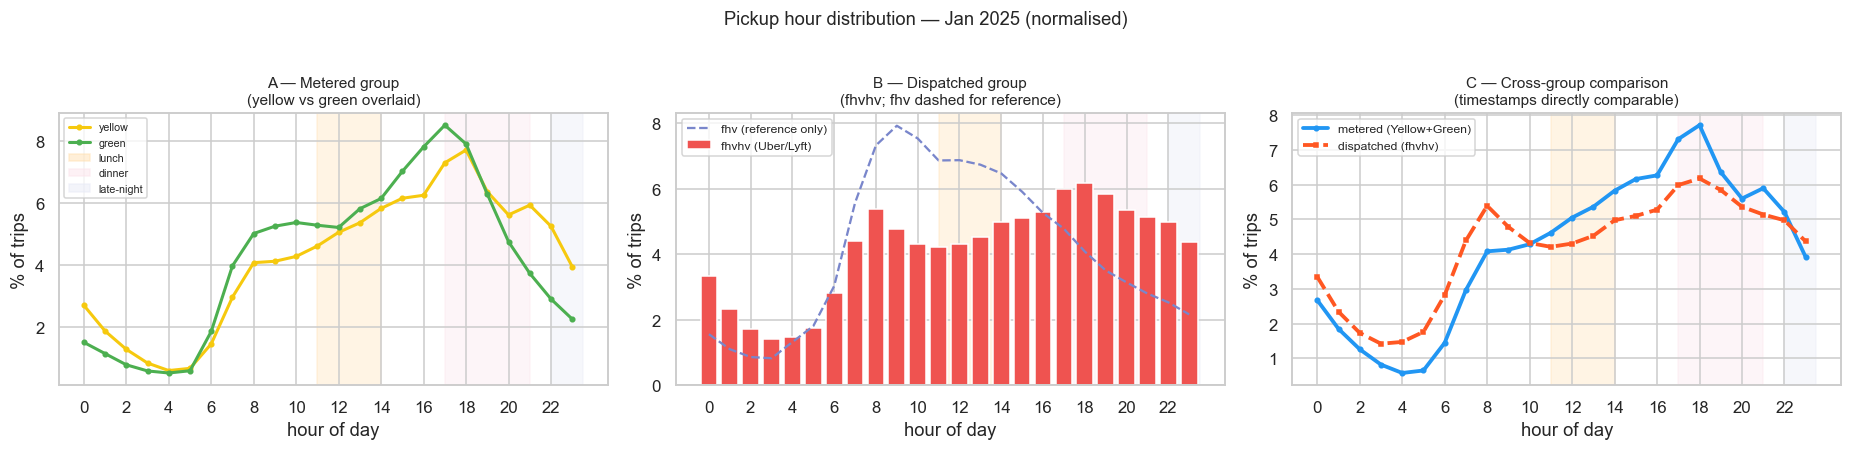

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4), sharey=False)
hours = range(24)

# ── Plot A: Metered group — yellow vs green overlaid ────────────────────────
ax = axes[0]
add_meal_shading(ax)
for fleet in METERED:
    norm = hourly_norm[fleet].reindex(hours, fill_value=0)
    ax.plot(hours, norm.values, color=FLEET_COLORS[fleet], linewidth=2, label=fleet, marker="o", markersize=3)
ax.set_title("A — Metered group\n(yellow vs green overlaid)", fontsize=10)
ax.set_xlabel("hour of day")
ax.set_ylabel("% of trips")
ax.set_xticks(range(0, 24, 2))
ax.legend(fontsize=8)

# ── Plot B: Dispatched group — fhvhv (fhv for reference) ────────────────────
ax = axes[1]
add_meal_shading(ax)
norm_fhvhv = hourly_norm["fhvhv"].reindex(hours, fill_value=0)
ax.bar(hours, norm_fhvhv.values, color=FLEET_COLORS["fhvhv"], width=0.8, label="fhvhv (Uber/Lyft)", zorder=2)
norm_fhv = hourly_norm["fhv"].reindex(hours, fill_value=0)
ax.plot(hours, norm_fhv.values, color=FLEET_COLORS["fhv"], linewidth=1.5,
        linestyle="--", label="fhv (reference only)", zorder=3)
ax.set_title("B — Dispatched group\n(fhvhv; fhv dashed for reference)", fontsize=10)
ax.set_xlabel("hour of day")
ax.set_ylabel("% of trips")
ax.set_xticks(range(0, 24, 2))
ax.legend(fontsize=8)

# ── Plot C: Cross-group — metered aggregate vs fhvhv ────────────────────────
ax = axes[2]
add_meal_shading(ax)
ax.plot(hours, metered_agg.values, color=GROUP_COLORS["metered"], linewidth=2.5,
        label="metered (Yellow+Green)", marker="o", markersize=3)
ax.plot(hours, dispatched_agg.values, color=GROUP_COLORS["dispatched"], linewidth=2.5,
        label="dispatched (fhvhv)", linestyle="--", marker="s", markersize=3)
ax.set_title("C — Cross-group comparison\n(timestamps directly comparable)", fontsize=10)
ax.set_xlabel("hour of day")
ax.set_ylabel("% of trips")
ax.set_xticks(range(0, 24, 2))
ax.legend(fontsize=8)

# Shared meal-window legend on Plot A
meal_handles = [mpatches.Patch(color=c, alpha=0.5, label=lbl)
                for lbl, _, _, c in MEAL_WINDOWS]
axes[0].legend(handles=[*axes[0].get_legend_handles_labels()[0], *meal_handles], fontsize=7)

fig.suptitle("Pickup hour distribution — Jan 2025 (normalised)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

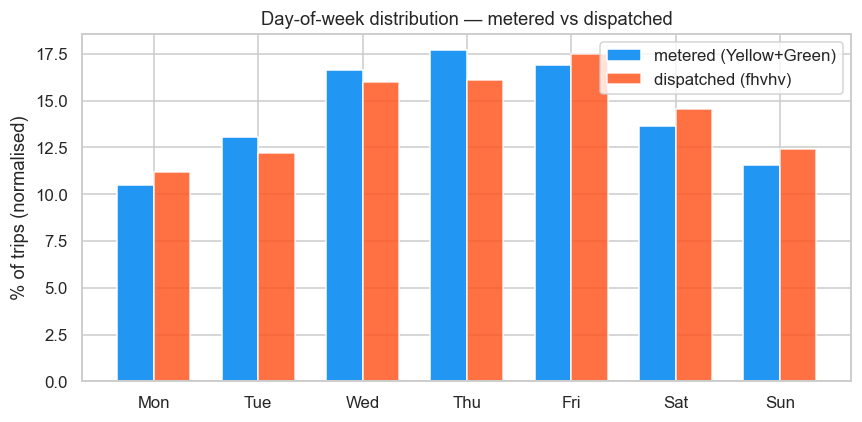

Dinner-hour (17–21h) share of all trips:
  metered aggregate      32.9%
  fhvhv                  28.5%
  fhv (reference)        18.3%


In [13]:
# Day-of-week: group overlays (metered aggregate vs fhvhv)
DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_idx = range(7)

metered_dow = group_aggregate(METERED,   dow_norm, row_counts, dow_idx)
fhvhv_dow   = group_aggregate(["fhvhv"], dow_norm, row_counts, dow_idx)

fig, ax = plt.subplots(figsize=(8, 4))
x     = list(dow_idx)
width = 0.35
ax.bar([xi - width / 2 for xi in x], metered_dow.values, width=width,
       color=GROUP_COLORS["metered"], label="metered (Yellow+Green)")
ax.bar([xi + width / 2 for xi in x], fhvhv_dow.values, width=width,
       color=GROUP_COLORS["dispatched"], label="dispatched (fhvhv)", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(DOW_LABELS)
ax.set_ylabel("% of trips (normalised)")
ax.set_title("Day-of-week distribution — metered vs dispatched")
ax.legend()
plt.tight_layout()
plt.show()

# Dinner-hour share summary
print("Dinner-hour (17–21h) share of all trips:")
print(f"  {'metered aggregate':<22} {sum(metered_agg.iloc[h] for h in range(17, 22)):.1f}%")
print(f"  {'fhvhv':<22} {sum(hourly_norm['fhvhv'].get(h, 0) for h in range(17, 22)):.1f}%")
print(f"  {'fhv (reference)':<22} {sum(hourly_norm['fhv'].get(h, 0) for h in range(17, 22)):.1f}%")